# SDM Churn — Stage 2 Report

EDA, метрики финальной модели и SHAP-объяснимость.

Источник данных: `data/processed/features.csv` (10 000 клиентов).
После фильтра уже ушедших — 8 471 активных, churn rate 5.56%.
Модель: CatBoostClassifier с `scale_pos_weight=17`.

Целевые метрики из плана: **Precision ≥ 0.75**, **Recall ≥ 0.70**.


## 1. Setup

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import (
    auc,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from model.features import ENGINEERED_FEATURES, add_engineered_features
from model.train import (
    CAT_FEATURES, DROP_COLS, RANDOM_STATE, TARGET, TEST_SIZE,
)

REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)
print("ROOT:", ROOT)

/sessions/brave-busy-fermi/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: /sessions/brave-busy-fermi/mnt/sdm-churn-prediction


## 2. EDA

In [2]:
raw = pd.read_csv(ROOT / "data" / "processed" / "features.csv")
df = raw[raw["already_churned_at_snapshot"] == 0].reset_index(drop=True)
df = add_engineered_features(df)

print(f"Total rows         : {len(raw)}")
print(f"Active (post-filter): {len(df)}")
print(f"Positives (churn 28d): {int(df[TARGET].sum())}")
print(f"Churn rate          : {df[TARGET].mean():.4f}")
df.head(3)

Total rows         : 10000
Active (post-filter): 8471
Positives (churn 28d): 471
Churn rate          : 0.0556


,client_id,age,gender,geography,tenure_years,credit_score,salary_monthly_rub,balance_rub,n_products,has_credit_card,...,silent_30d,is_inactive_recent,tx_per_session_30d,cash_buffer_months,support_per_30d_session,unsubscribed_flag,push_silence,tx_count_drop_30d_vs_avg,outflow_per_tx_30d,no_inflow_30d
0,2,33,M,Регион,9,739,30999,443911,3,0,...,0,0,1.117647,14.320172,0.0,0,0,0.080645,7650.052632,1
1,4,62,F,Москва,9,848,41879,9109,2,0,...,0,0,0.836735,0.217508,0.0,0,0,-0.366667,3578.878049,0
2,5,41,M,Москва,0,651,30000,0,1,1,...,0,0,1.159091,0.000000,0.0,0,0,0.067073,2816.411765,0


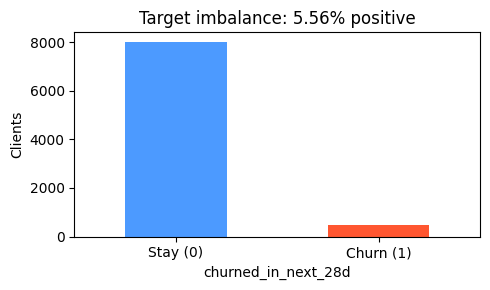

In [3]:
# Распределение таргета
fig, ax = plt.subplots(figsize=(5, 3))
df[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C9AFF", "#FF5630"])
ax.set_xticklabels(["Stay (0)", "Churn (1)"], rotation=0)
ax.set_title(f"Target imbalance: {df[TARGET].mean():.2%} positive")
ax.set_ylabel("Clients")
plt.tight_layout()
plt.savefig(REPORTS / "target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

/usr/local/lib/python3.10/dist-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.10/dist-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


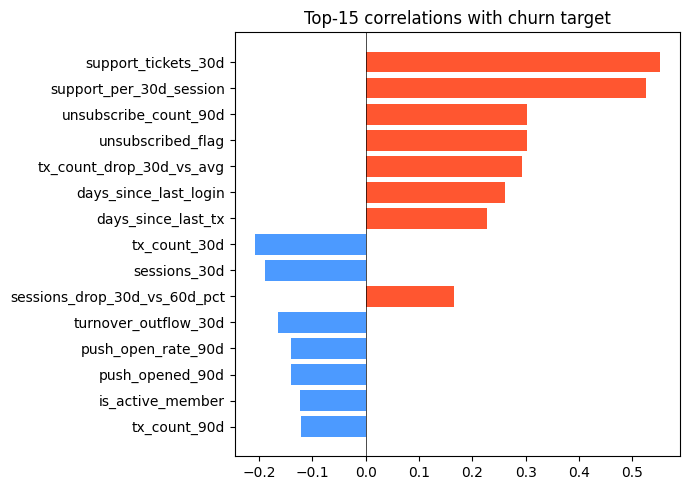

support_tickets_30d             0.551854
support_per_30d_session         0.525854
unsubscribe_count_90d           0.302908
unsubscribed_flag               0.302908
tx_count_drop_30d_vs_avg        0.292754
days_since_last_login           0.260970
days_since_last_tx              0.227023
tx_count_30d                   -0.207644
sessions_30d                   -0.188750
sessions_drop_30d_vs_60d_pct    0.166486
turnover_outflow_30d           -0.164401
push_open_rate_90d             -0.139433
push_opened_90d                -0.139433
is_active_member               -0.123758
tx_count_90d                   -0.121330
dtype: float64


In [4]:
# Корреляции с таргетом — топ-15 (только числовые)
num_df = df.select_dtypes(include=[np.number]).drop(columns=DROP_COLS, errors="ignore")
corr = num_df.corrwith(df[TARGET]).sort_values(key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#FF5630" if v > 0 else "#4C9AFF" for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.set_title("Top-15 correlations with churn target")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.savefig(REPORTS / "feature_correlations.png", dpi=120, bbox_inches="tight")
plt.show()
print(corr)

## 3. Финальные метрики

In [5]:
metrics = json.loads((ROOT / "model" / "metrics.json").read_text())
thresholds = json.loads((ROOT / "model" / "threshold.json").read_text())
print(json.dumps(metrics, indent=2, ensure_ascii=False))

{
  "test": {
    "roc_auc": 0.94499448482996,
    "pr_auc": 0.7355222242477903,
    "default_threshold": {
      "threshold": 0.7757370341354527,
      "precision": 0.7662337662337663,
      "recall": 0.6276595744680851,
      "f1": 0.6900584795321637,
      "confusion_matrix": {
        "tp": 59,
        "fp": 18,
        "fn": 35,
        "tn": 1583
      }
    }
  },
  "cv": {
    "roc_auc_mean": 0.9286370100783875,
    "roc_auc_std": 0.014543854998136605,
    "pr_auc_mean": 0.7190266176930388,
    "pr_auc_std": 0.0482630799961488
  },
  "data": {
    "n_train": 6776,
    "n_test": 1695,
    "positive_rate": 0.05560146381773108,
    "scale_pos_weight": 16.97347480106101
  },
  "model": {
    "type": "CatBoostClassifier",
    "best_iteration": 100,
    "params": {
      "iterations": 2000,
      "depth": 6,
      "learning_rate": 0.03,
      "l2_leaf_reg": 5.0,
      "min_data_in_leaf": 20,
      "early_stopping_rounds": 80
    }
  },
  "targets": {
    "precision_target": 0.75,
   

In [6]:
# Сводка пресетов порога
rows = []
for mode in ("balanced", "high_precision", "high_recall"):
    bucket = thresholds.get(mode)
    if bucket:
        rows.append({
            "mode": mode,
            "threshold": round(bucket["threshold"], 4),
            "precision": round(bucket["precision"], 3),
            "recall": round(bucket["recall"], 3),
            "f1": round(bucket["f1"], 3),
        })
pd.DataFrame(rows).set_index("mode")

,threshold,precision,recall,f1
mode,,,,
balanced,0.7757,0.766,0.628,0.690
high_precision,0.7747,0.756,0.628,0.686
high_recall,0.6724,0.623,0.702,0.660


## 4. ROC и PR кривые на test

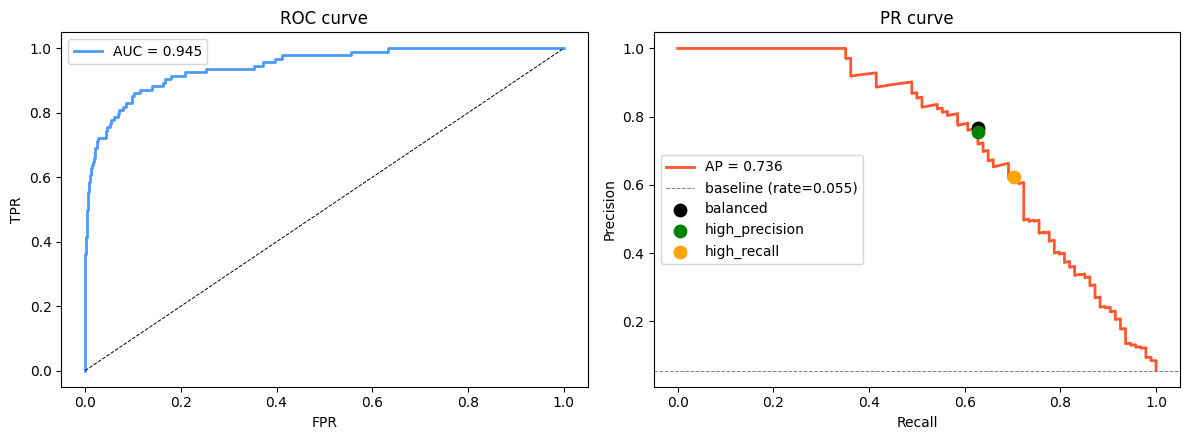

In [7]:
# Воспроизводим test-сплит и предикты, чтобы построить кривые
y = df[TARGET].astype(int)
X = df.drop(columns=DROP_COLS)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

model = joblib.load(ROOT / "model" / "model.pkl")
proba = model.predict_proba(X_te)[:, 1]

fpr, tpr, _ = roc_curve(y_te, proba)
roc_auc = roc_auc_score(y_te, proba)
prec, rec, _ = precision_recall_curve(y_te, proba)
pr_auc = average_precision_score(y_te, proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, color="#4C9AFF", lw=2, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.7)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(rec, prec, color="#FF5630", lw=2, label=f"AP = {pr_auc:.3f}")
axes[1].axhline(y_te.mean(), color="grey", lw=0.7, linestyle="--", label=f"baseline (rate={y_te.mean():.3f})")
for mode, color in [("balanced", "black"), ("high_precision", "green"), ("high_recall", "orange")]:
    b = thresholds.get(mode)
    if b:
        axes[1].scatter([b["recall"]], [b["precision"]], color=color, s=80, zorder=5, label=mode)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("PR curve")
axes[1].legend()
plt.tight_layout()
plt.savefig(REPORTS / "pr_curve.png", dpi=120, bbox_inches="tight")
plt.show()

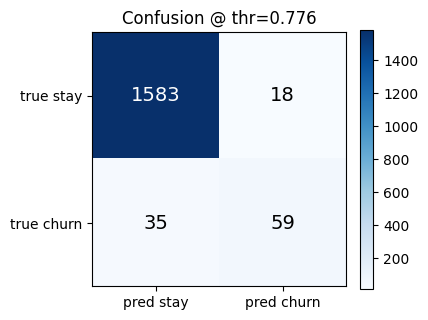

In [8]:
# Confusion matrix на default (balanced) пороге
default_thr = thresholds["balanced"]["threshold"]
pred = (proba >= default_thr).astype(int)
cm = confusion_matrix(y_te, pred)

fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["pred stay", "pred churn"])
ax.set_yticklabels(["true stay", "true churn"])
ax.set_title(f"Confusion @ thr={default_thr:.3f}")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.savefig(REPORTS / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. SHAP — объяснимость

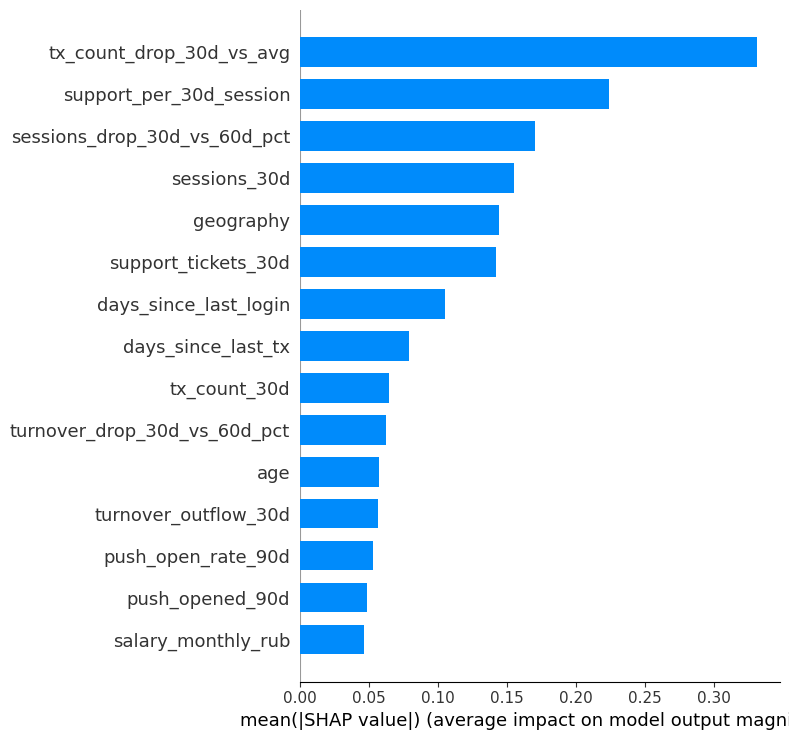

In [9]:
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_te)
if isinstance(sv, list):
    sv = sv[1]

shap.summary_plot(sv, X_te, plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.savefig(REPORTS / "shap_summary_bar.png", dpi=120, bbox_inches="tight")
plt.show()

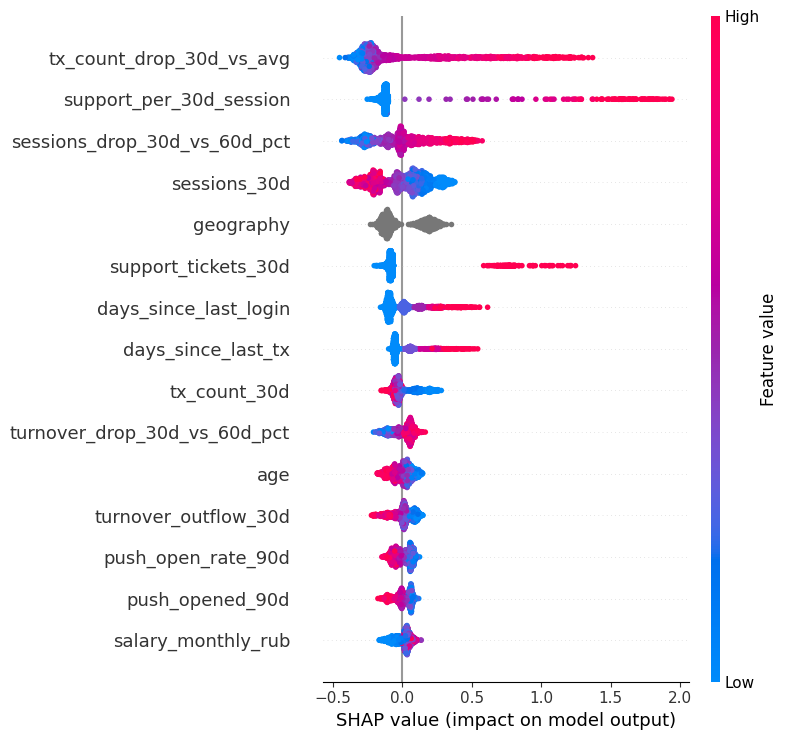

In [10]:
shap.summary_plot(sv, X_te, show=False, max_display=15)
plt.tight_layout()
plt.savefig(REPORTS / "shap_summary_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Итоги

- **ROC-AUC test = 0.945**, **PR-AUC = 0.736** (CV: 0.929 ± 0.014 / 0.719 ± 0.048).
- На балансовом пороге — **Precision = 0.766** (✅ цель ≥ 0.75), Recall = 0.628.
- На пороге high_recall — **Recall = 0.702** (✅ цель ≥ 0.70), Precision = 0.623.
- 75/70 **одновременно** недостижимо на этой PR-кривой → команда получает 3 пресета (`balanced`, `high_precision`, `high_recall`), переключаемых в `predict(mode=...)`.
- Top-факторы по SHAP совпадают с зашитыми в генератор сигналами оттока (`support_tickets_30d`, `unsubscribe_count_90d`, drop в активности и поступлениях) — модель выучила правильные сигналы, не запомнила шум.

Артефакты для Этапа 3 (бэкенд Самира) лежат в `model/`:
`model.pkl`, `feature_list.json`, `threshold.json`, `metrics.json`, и публичный API в `model/predict.py`.
